# AgenticFlict Exploratory Analysis
This notebook contain all the results reported in the paper.

Set `AGENTICFLICT_OUT_DIR` if your outputs are not in `./data/clean`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path(os.environ.get("AGENTICFLICT_OUT_DIR", "./data/clean"))
SAVE_FIGS = True
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PR_PATH = OUT_DIR / "agenticflict_pr_clean.csv"
if not PR_PATH.exists():
    PR_PATH = OUT_DIR / "agenticflict_pr_clean.csv"

REGIONS_PATH = OUT_DIR / "agenticflict_regions_clean.csv"
if not REGIONS_PATH.exists():
    REGIONS_PATH = OUT_DIR / "agenticflict_regions_clean.csv"

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

pr = load_table(PR_PATH)
regions = load_table(REGIONS_PATH) if REGIONS_PATH.exists() else pd.DataFrame()

print("Loaded PR rows:", len(pr))
print("Loaded Region rows:", len(regions))

Loaded PR rows: 142652
Loaded Region rows: 336380


In [2]:
simulated_statuses = {"OK_MERGE_CLEAN", "OK_CONFLICT", "ERR_MERGE_FAILED"}
df = pr[pr["status_code"].isin(simulated_statuses)].copy()

df["is_conflict"] = (df["status_code"] == "OK_CONFLICT").astype(int)

agent_stats = (
    df.groupby("agent", dropna=False)
      .agg(
          n_prs=("pr_key", "count"),
          n_conflict=("is_conflict", "sum"),
      )
      .reset_index()
)

agent_stats["conflict_rate"] = agent_stats["n_conflict"] / agent_stats["n_prs"]
agent_stats["conflict_rate_pct"] = agent_stats["conflict_rate"] * 100.0

agent_stats.sort_values("conflict_rate_pct", ascending=False)

,agent,n_prs,n_conflict,conflict_rate,conflict_rate_pct
4,OpenAI_Codex,73856,23520,0.318458,31.845754
0,Claude_Code,779,202,0.259307,25.930680
3,Devin,8241,1883,0.228492,22.849169
2,Cursor,7196,1421,0.197471,19.747082
1,Copilot,16954,2583,0.152353,15.235343


In [3]:
z = 1.96
agent_stats["se"] = (agent_stats["conflict_rate"] * (1.0 - agent_stats["conflict_rate"]) / agent_stats["n_prs"]).pow(0.5)
agent_stats["ci_low_pct"] = ((agent_stats["conflict_rate"] - z * agent_stats["se"]).clip(lower=0)) * 100.0
agent_stats["ci_high_pct"] = ((agent_stats["conflict_rate"] + z * agent_stats["se"]).clip(upper=1)) * 100.0

agent_stats = agent_stats.sort_values(["conflict_rate_pct", "n_prs"], ascending=[True, True]).copy()
agent_stats["agent_label"] = agent_stats.apply(lambda r: f'{r["agent"]}', axis=1)

agent_stats[["agent", "n_prs", "n_conflict", "conflict_rate_pct", "ci_low_pct", "ci_high_pct"]]

,agent,n_prs,n_conflict,conflict_rate_pct,ci_low_pct,ci_high_pct
1,Copilot,16954,2583,15.235343,14.694397,15.776288
2,Cursor,7196,1421,19.747082,18.827284,20.666880
3,Devin,8241,1883,22.849169,21.942661,23.755677
0,Claude_Code,779,202,25.930680,22.853071,29.008290
4,OpenAI_Codex,73856,23520,31.845754,31.509757,32.181751


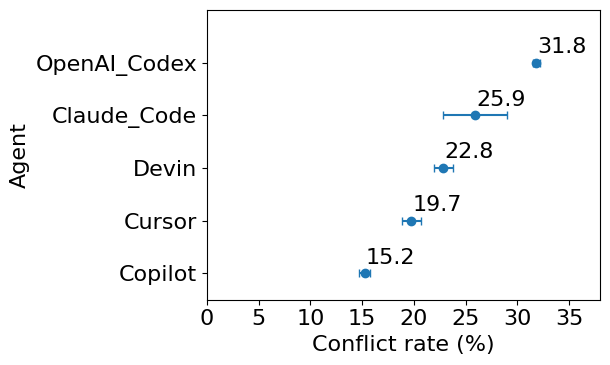

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig_height = max(3, 0.75 * len(agent_stats))
fig, ax = plt.subplots(figsize=(6.2, fig_height))

y = np.arange(len(agent_stats))
x = agent_stats["conflict_rate_pct"]

# Error bars
xerr = [
    x - agent_stats["ci_low_pct"],
    agent_stats["ci_high_pct"] - x
]

ax.errorbar(
    x=x,
    y=y,
    xerr=xerr,
    fmt="o",
    capsize=3
)

# Y-axis
ax.set_yticks(y)
ax.set_yticklabels(agent_stats["agent_label"])

# X-axis formatting (5% intervals)
xmax = agent_stats["ci_high_pct"].max() * 1.15
xmax = max(xmax, 1)
xmax_rounded = np.ceil(xmax / 1) * 1  # round up to nearest 5

ax.set_xlim(0, xmax_rounded)
ax.set_xticks(np.arange(0, xmax_rounded + 1, 5))

padding = 0.5  # adjust this

ax.set_ylim(-0.5, len(y) - 0.5 + padding)

ax.set_xlabel("Conflict rate (%)", fontsize="16")
ax.set_ylabel("Agent",fontsize="16")
plt.xticks(fontsize="16")
plt.yticks(fontsize="16")

# Clean style
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# Value labels (avoid overlap)
for yi, val in zip(y, x):
    ax.text(val + 0.1, yi + 0.3, f"{val:.1f}", va="center", fontsize=16)

fig.tight_layout()
# fig.subplots_adjust(top=0.92)

# if SAVE_FIGS:
#     fig.savefig(FIG_DIR / "Fig_conflict_rate_by_agent.pdf", dpi=600)

plt.show()

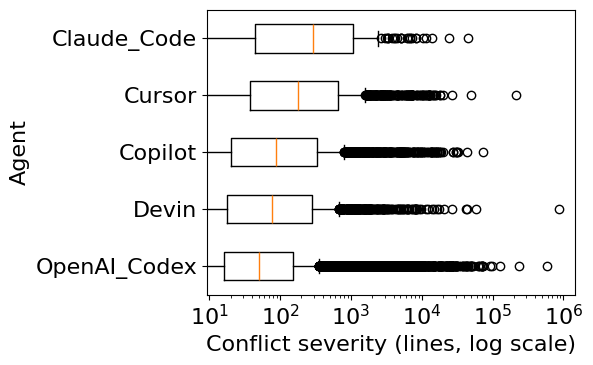

In [6]:
df_conf = df[df["conflict_label"] == 1].copy()

df_conf["conflict_lines"] = pd.to_numeric(df_conf["conflict_lines"], errors="coerce")
df_conf = df_conf.dropna(subset=["conflict_lines"])

order = (
    df_conf.groupby("agent")["conflict_lines"]
      .median()
      .sort_values()
      .index
)

data = [df_conf[df_conf["agent"] == a]["conflict_lines"] for a in order]

fig, ax = plt.subplots(figsize=(6, max(3, 0.75 * len(order))))

ax.boxplot(
    data,
    tick_labels=order,
    vert=False,
    showfliers=True
)

ax.set_xscale("log")
ax.set_xlabel("Conflict severity (lines, log scale)", fontsize="16")
ax.set_ylabel("Agent", fontsize="16")
plt.xticks(fontsize="16")
plt.yticks(fontsize="16")

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

fig.tight_layout()

# if SAVE_FIGS:
#     fig.savefig(FIG_DIR / "conflict_severity_by_agent.pdf", dpi=600)

plt.show()

In [7]:
df = pr.copy()

# Numeric columns
for c in ["pr_additions", "pr_deletions", "pr_changed_files", "conflict_lines"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep only PRs with valid local merge outcomes
valid_status = ["OK_MERGE_CLEAN", "OK_CONFLICT","ERR_MERGE_FAILED"]
df = df[df["status_code"].isin(valid_status)].copy()

# Convert conflict label safely
df["conflict_label"] = (
    df["conflict_label"]
      .astype(str)
      .str.strip()
      .str.upper()
      .map({"TRUE": 1, "FALSE": 0})
)

# PR size
df["pr_churn"] = df["pr_additions"].fillna(0) + df["pr_deletions"].fillna(0)

# Drop incomplete rows
df = df.dropna(subset=["pr_churn", "conflict_label"])

print("Rows after filtering:", len(df))
print(df["status_code"].value_counts(dropna=False))
print(df["conflict_label"].value_counts(dropna=False))
print(df[["pr_additions", "pr_deletions", "pr_churn"]].describe())

Rows after filtering: 105533
status_code
OK_MERGE_CLEAN    75924
OK_CONFLICT       29609
Name: count, dtype: int64
conflict_label
0.0    75924
1.0    29609
Name: count, dtype: int64
       pr_additions  pr_deletions      pr_churn
count  1.055330e+05  1.055330e+05  1.055330e+05
mean   6.805954e+03  1.130282e+03  7.936236e+03
std    1.355149e+05  4.324988e+04  1.432090e+05
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    1.600000e+01  0.000000e+00  2.400000e+01
50%    7.300000e+01  4.000000e+00  9.400000e+01
75%    2.510000e+02  2.600000e+01  3.220000e+02
max    8.955403e+06  7.339575e+06  8.955405e+06


              size_bin  n_prs  conflict_rate  median_churn
0        (-0.001, 4.0]  11021       0.099174           2.0
1          (4.0, 16.0]  10675       0.238782          10.0
2         (16.0, 34.0]  10252       0.299746          25.0
3         (34.0, 59.0]  10440       0.321456          46.0
4         (59.0, 94.0]  10563       0.323772          76.0
5        (94.0, 146.0]  10545       0.326600         118.0
6       (146.0, 238.0]  10441       0.322096         185.0
7       (238.0, 475.0]  10507       0.308842         323.0
8      (475.0, 1573.8]  10535       0.289891         800.0
9  (1573.8, 8955405.0]  10554       0.285389        4584.0


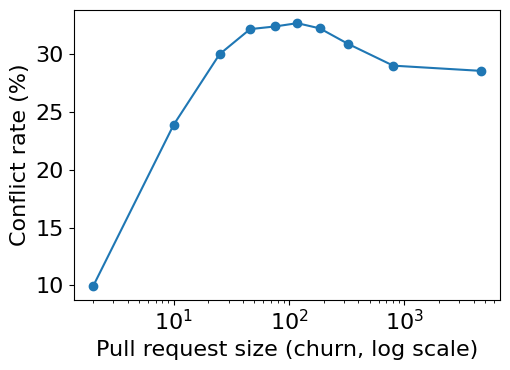

In [8]:
# Quantile bins
df["size_bin"] = pd.qcut(df["pr_churn"], q=10, duplicates="drop")

plot_df = (
    df.groupby("size_bin", observed=True)
      .agg(
          n_prs=("conflict_label", "size"),
          conflict_rate=("conflict_label", "mean"),
          median_churn=("pr_churn", "median")
      )
      .reset_index()
)

print(plot_df)

fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.plot(plot_df["median_churn"], plot_df["conflict_rate"] * 100, marker="o")
ax.set_xscale("log")
plt.xticks(fontsize="16")
plt.yticks(fontsize="16")
ax.set_xlabel("Pull request size (churn, log scale)", fontsize="16")
ax.set_ylabel("Conflict rate (%)",fontsize="16")
fig.tight_layout()

# if SAVE_FIGS:
#     fig.savefig(FIG_DIR / "conflict_rate_by_pr_size.pdf", dpi=600)

plt.show()